In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ==========================================
# 0. 全局设置：Mac苹果电脑 中文显示配置
# ==========================================
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
sns.set_theme(style="whitegrid", font="Arial Unicode MS") # 让 seaborn 也使用中文字体

# ==========================================
# 1. 数据加载与基础清洗
# ==========================================
print("⏳ 正在加载数据...")
try:
    df_news = pd.read_csv('news final(1).csv')
    df_post = pd.read_csv('post(1).csv')
    
    # 兼容处理第一行可能是无效数据的情况
    if 'post_id' in df_post.columns and pd.isna(df_post['post_id'].iloc[0]):
        df_post = df_post.iloc[1:]
except FileNotFoundError as e:
    print(f"❌ 找不到文件，请检查文件名或路径: {e}")
    exit()

# 统一列名
df_news = df_news.rename(columns={'news_id': 'id', 'fraud_type': 'fraud_category'})
df_post = df_post.rename(columns={'post_id': 'id'})
df_news['data_source'] = '新闻报道'
df_post['data_source'] = '社交媒体'

# 提取核心列并合并
core_cols = ['id', 'data_source', 'fraud_category', 'age_group', 'occupation', 'economy', 'fund_behavior', 'decision_trait', 'jung_type']
df_news_core = df_news[[c for c in core_cols if c in df_news.columns]]
df_post_core = df_post[[c for c in core_cols if c in df_post.columns]]

df_merged = pd.concat([df_news_core, df_post_core], axis=0, ignore_index=True)
df_merged = df_merged.fillna('未知')


# ==========================================
# 2. 中文到中文的降维与标准化 (核心清洗)
# ==========================================
def clean_and_standardize(text, mapping_rules, default='其他'):
    if pd.isna(text) or text == 'Unknown' or text == '未知' or str(text).strip() == '':
        return '未知'
    text = str(text)
    for keywords, std_translation in mapping_rules.items():
        if any(keyword in text for keyword in keywords):
            return std_translation
    return default

# 定义标准的中文大类映射规则
rules_fraud = {
    ('刷单', '兼职'): '刷单返利类', ('投资', '理财', '招商', '项目'): '虚假投资理财类',
    ('贷款', '征信', '银行', '金融', '代办'): '虚假贷款/代办类', ('电商', '物流', '客服', '购物'): '冒充电商物流类',
    ('婚恋', '交友', '杀猪盘'): '婚恋交友/杀猪盘', ('公检法', '军警'): '冒充公检法类',
    ('领导', '熟人', '老师'): '冒充熟人/领导类', ('游戏', '赌博'): '网络游戏/赌博类',
    ('招聘', '劳务', '录取', '招生'): '虚假招聘/招生类', ('医疗', '报销'): '虚假医疗/报销类'
}
rules_age = {
    ('青少', '13', '未成年', '18岁以下', '<18', '十多岁'): '18岁以下', 
    ('青年', '18', '20', '二三十', '18-25'): '18-25岁', 
    ('26', '30', '35', '三十', '26-35'): '26-35岁',
    ('中年', '36', '四十', '40', '36-45'): '36-45岁',
    ('46', '50', '五十', '46-55'): '46-55岁',
    ('老', '60', '退休', '大爷', '大妈', '55岁以上', '>55'): '55岁以上'
}
rules_occ = {
    ('学生',): '学生', ('职员', '白领', '公务员', '公司', '上班'): '企事业员工', 
    ('务工', '工人', '保洁', '司机', '打工'): '务工人员', ('无业', '待业', '家庭主妇', '主夫', '全职妈妈'): '无业/家庭主妇', 
    ('个体', '经商', '老板', '做生意'): '个体户/商人', ('退休',): '退休人员', 
    ('教师',): '教师', ('医', '护'): '医护人员', ('律师', '法官'): '法律工作者'
}
rules_eco = {('低', '贫', '没钱', '负债'): '低收入', ('中', '小康'): '中等收入', ('高', '富', '优渥'): '高收入'}
rules_fund = {
    ('大额', '重金', '几十万', '百万', '倾家荡产'): '大额投入', ('多次', '陆续', '继续'): '多次转账', 
    ('小额', '试水', '几百', '一点'): '小额试水', ('未', '无', '尚未', '拒绝', '没有', '没', '止损'): '未转账/被劝阻',
    ('提供账户', '出租账户', '洗钱', '跑分'): '提供账户/涉嫌帮信'
}
rules_decision = {
    ('冲动', '情绪', '紧张', '急于', '害怕', '恐慌'): '冲动/焦虑', ('盲目', '轻信', '好奇', '信任'): '盲目轻信', 
    ('贪', '侥幸', '赚钱', '高息', '返利'): '贪利/侥幸', ('谨慎', '核实', '咨询', '报警', '反思', '质疑', '拆解', '识破'): '谨慎/已核实',
    ('犹豫', '半信半疑'): '犹豫不决'
}

df_merged['fraud_category'] = df_merged['fraud_category'].apply(lambda x: clean_and_standardize(x, rules_fraud, default='其他诈骗'))
df_merged['age_group'] = df_merged['age_group'].apply(lambda x: clean_and_standardize(x, rules_age))
df_merged['occupation'] = df_merged['occupation'].apply(lambda x: clean_and_standardize(x, rules_occ))
df_merged['economy'] = df_merged['economy'].apply(lambda x: clean_and_standardize(x, rules_eco))
df_merged['fund_behavior'] = df_merged['fund_behavior'].apply(lambda x: clean_and_standardize(x, rules_fund))
df_merged['decision_trait'] = df_merged['decision_trait'].apply(lambda x: clean_and_standardize(x, rules_decision))

print("✅ 中文数据降维与标准化清洗完成！")

⏳ 正在加载数据...
✅ 中文数据降维与标准化清洗完成！


📊 过滤后用于聚类的高质量样本数量: 495 条
🔍 正在计算肘部法则评估最佳 K 值...


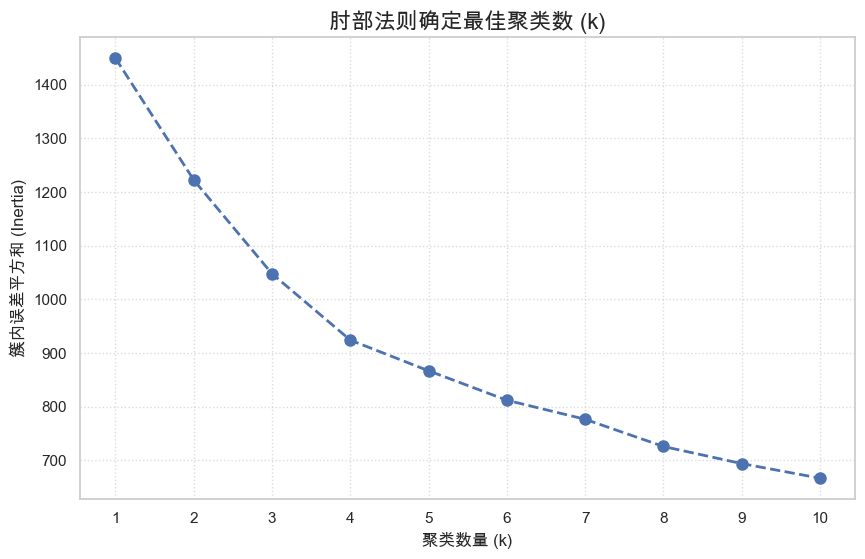

✅ 肘部法则图已保存为 'elbow_method_plot_CN.png'。请查看曲线变平缓的“拐点”。


In [15]:
# ==========================================
# 3. 深度过滤与特征编码
# ==========================================
# 剔除掉关键信息为“未知”或属于“其他”类别的模糊数据
df_for_modeling = df_merged[
    (df_merged['age_group'] != '未知') & 
    (df_merged['occupation'] != '未知') &
    (df_merged['decision_trait'] != '未知') &
    (df_merged['fraud_category'] != '其他诈骗')
].copy()

print(f"📊 过滤后用于聚类的高质量样本数量: {len(df_for_modeling)} 条")

if len(df_for_modeling) < 10:
    print("❌ 警告：有效样本太少，无法进行 K-Means，请放宽过滤条件。")
    exit()

cluster_features = ['age_group', 'occupation', 'economy', 'fund_behavior', 'decision_trait']
df_encoded = pd.get_dummies(df_for_modeling[cluster_features]).astype(int)


# ==========================================
# 4. 肘部法则 (Elbow Method) 寻找最佳 K 值
# ==========================================
print("🔍 正在计算肘部法则评估最佳 K 值...")
inertias = []
max_k = min(11, len(df_for_modeling) + 1)
k_range = range(1, max_k)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(df_encoded)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='--', color='b', linewidth=2, markersize=8)
plt.title('肘部法则确定最佳聚类数 (k)', fontsize=16, fontweight='bold')
plt.xlabel('聚类数量 (k)', fontsize=12)
plt.ylabel('簇内误差平方和 (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('elbow_method_plot_CN.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 肘部法则图已保存为 'elbow_method_plot_CN.png'。请查看曲线变平缓的“拐点”。")

⚙️ 正在执行 K-Means 聚类 (当前设定 K=4)...


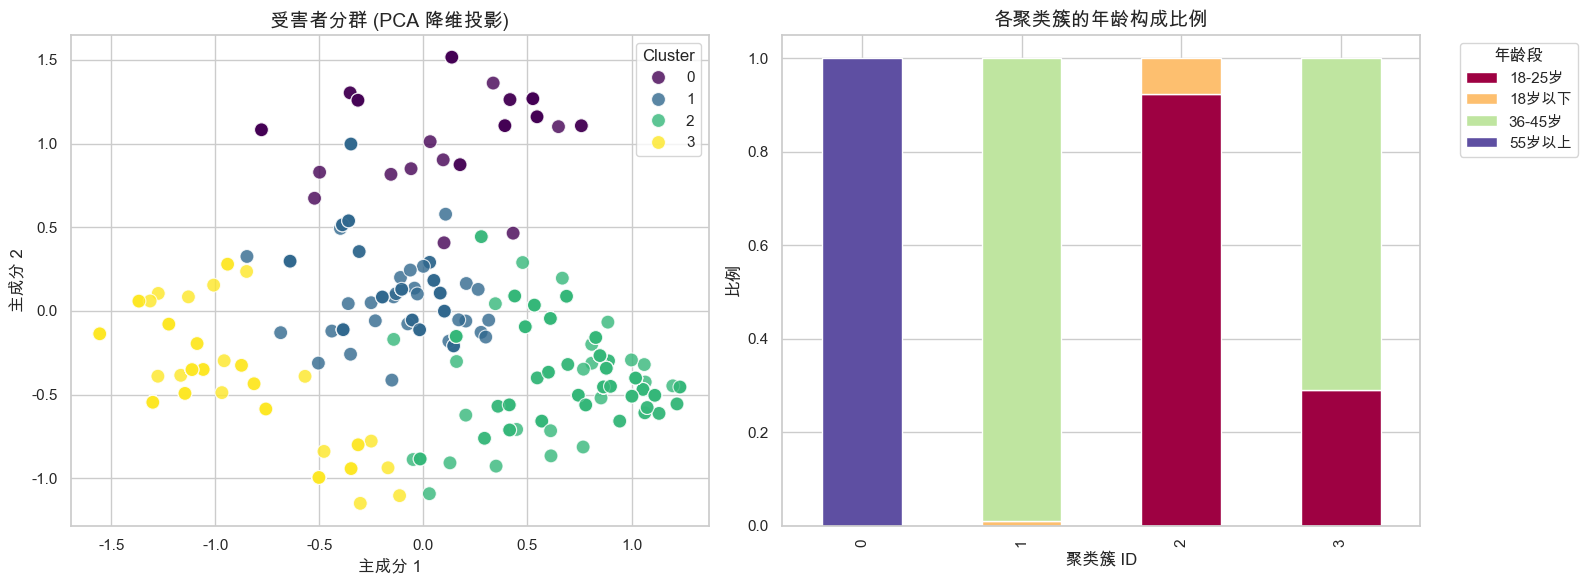

✅ 聚类散点图已保存为 'kmeans_clusters_pca_CN.png'。


In [16]:
# ==========================================
# 5. 执行 K-Means 与 PCA 可视化
# ==========================================
K = 4 
print(f"⚙️ 正在执行 K-Means 聚类 (当前设定 K={K})...")

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_for_modeling['Cluster'] = kmeans.fit_predict(df_encoded)

# PCA 散点图与维度构成图
fig = plt.figure(figsize=(16, 6))

# 子图 1: PCA 散点图
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_encoded)
ax1 = plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_for_modeling['Cluster'], palette='viridis', s=100, ax=ax1, alpha=0.8)
ax1.set_title('受害者分群 (PCA 降维投影)', fontsize=14, fontweight='bold')
ax1.set_xlabel('主成分 1')
ax1.set_ylabel('主成分 2')

# 子图 2: 关键维度构成图 (不同簇的年龄分布)
ax2 = plt.subplot(1, 2, 2)
crosstab_age = pd.crosstab(df_for_modeling['Cluster'], df_for_modeling['age_group'], normalize='index')
crosstab_age.plot(kind='bar', stacked=True, colormap='Spectral', ax=ax2)
ax2.set_title('各聚类簇的年龄构成比例', fontsize=14, fontweight='bold')
ax2.set_xlabel('聚类簇 ID')
ax2.set_ylabel('比例')
ax2.legend(title='年龄段', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('kmeans_clusters_pca_CN.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 聚类散点图已保存为 'kmeans_clusters_pca_CN.png'。")


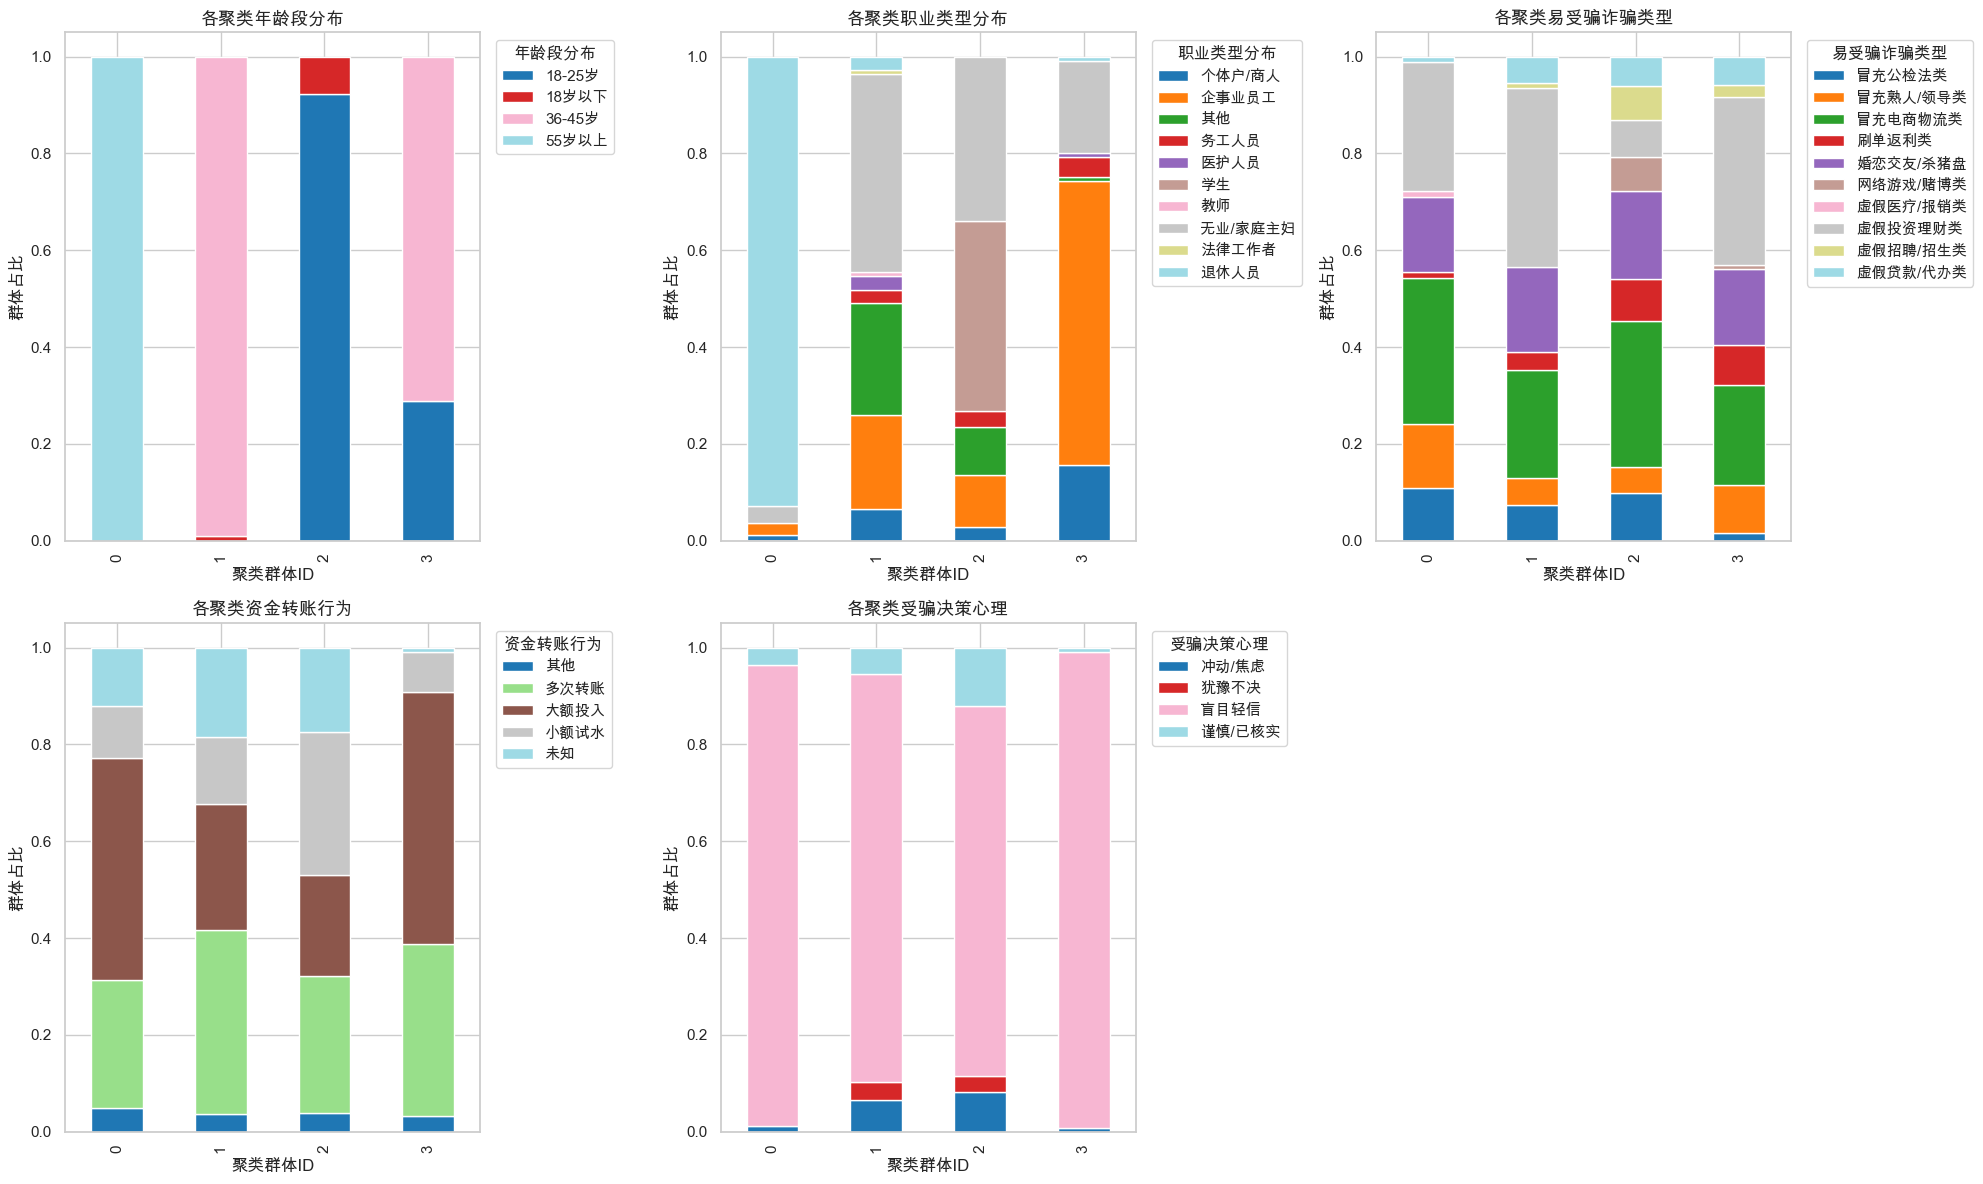

✅ 全维度人群特征对比图已保存：all_cluster_features.png


In [17]:
# ===================== 新增：全维度聚类特征分布对比 =====================
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Arial Unicode MS")

# 要展示的全部核心维度
show_features = ['age_group', 'occupation', 'fraud_category', 'fund_behavior', 'decision_trait']
feature_name = {
    'age_group':'年龄段分布',
    'occupation':'职业类型分布',
    'fraud_category':'易受骗诈骗类型',
    'fund_behavior':'资金转账行为',
    'decision_trait':'受骗决策心理'
}

# 2行3列大图，一次性展示所有维度
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, col in enumerate(show_features):
    # 计算每个簇内各特征占比
    cross = pd.crosstab(df_for_modeling['Cluster'], df_for_modeling[col], normalize='index')
    cross.plot(kind='bar', stacked=True, ax=axes[idx], colormap='tab20')
    axes[idx].set_title(f'各聚类{feature_name[col]}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('聚类群体ID')
    axes[idx].set_ylabel('群体占比')
    axes[idx].legend(title=feature_name[col], bbox_to_anchor=(1.02, 1), loc='upper left')

# 隐藏多余空白子图
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('all_cluster_features.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 全维度人群特征对比图已保存：all_cluster_features.png")

In [18]:
# ==========================================
# 6. 自动生成纯中文精准画像报告
# ==========================================
report = ["="*60, f"受害者群体精准画像报告 (聚类数 K={K})", "="*60 + "\n"]

def get_top(series):
    if len(series) == 0: return "无数据"
    return series.value_counts().index[0]

for i in range(K):
    group = df_for_modeling[df_for_modeling['Cluster'] == i]
    size = len(group)
    pct = (size / len(df_for_modeling)) * 100
    
    top_age = get_top(group['age_group'])
    top_occ = get_top(group['occupation'])
    top_dec = get_top(group['decision_trait'])
    top_scam = get_top(group['fraud_category'])
    top_fund = get_top(group['fund_behavior'])
    
    line = f"💎 [群体 {i}] (人数: {size}, 占比: {pct:.1f}%)\n"
    line += f"    ➜ 基础画像 : {top_age}群体，以[{top_occ}]为主\n"
    line += f"    ➜ 心理弱点 : 主要是[{top_dec}]\n"
    line += f"    ➜ 易受骗局 : 最容易遭遇[{top_scam}]\n"
    line += f"    ➜ 资金行为 : 典型行为是[{top_fund}]\n"
    report.append(line)

# 保存报告
with open('refined_victim_report_CN.txt', 'w', encoding='utf-8') as f:
    f.write("\n".join(report))

# 保存带 Cluster 标签的最终数据
df_for_modeling.to_csv('final_refined_clusters_CN.csv', index=False, encoding='utf-8-sig')

print("✅ 深度分析全部完成！")
print("📂 您现在可以在文件夹中查看以下中文成果：")
print("   1. elbow_method_plot_CN.png (肘部法则图)")
print("   2. kmeans_clusters_pca_CN.png (聚类可视化)")
print("   3. refined_victim_report_CN.txt (受害者画像TXT报告)")
print("   4. final_refined_clusters_CN.csv (带聚类标签的数据)")


✅ 深度分析全部完成！
📂 您现在可以在文件夹中查看以下中文成果：
   1. elbow_method_plot_CN.png (肘部法则图)
   2. kmeans_clusters_pca_CN.png (聚类可视化)
   3. refined_victim_report_CN.txt (受害者画像TXT报告)
   4. final_refined_clusters_CN.csv (带聚类标签的数据)
